In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


O gasto total da folha salarial da empresa é R$ 2.614.343,30
----------------------------------------------------------------------
O faturamento total da empresa é R$ 5.519.160,00
----------------------------------------------------------------------
A porcentagen de funcionarios que fecharam ao menos uma venda é de 86.84%
----------------------------------------------------------------------
1. Faturamento por Área:


,Valor Contrato Total
Area,
Administrativo,4590630
Comercial,2575530
Financeiro,2930400
Logística,2793240
Operações,3214440


----------------------------------------------------------------------
2. Total de Funcionários por Área:


,Total de Funcionários
Area,
Administrativo,26
Comercial,26
Financeiro,18
Logística,21
Operações,23


----------------------------------------------------------------------
3. Resumo de Produtividade por Área:


,Valor Contrato Total,Total de Funcionários,Ticket Médio por Funcionário
Area,,,
Administrativo,4590630,26,176562.692308
Financeiro,2930400,18,162800.000000
Operações,3214440,23,139758.260870
Logística,2793240,21,133011.428571
Comercial,2575530,26,99058.846154


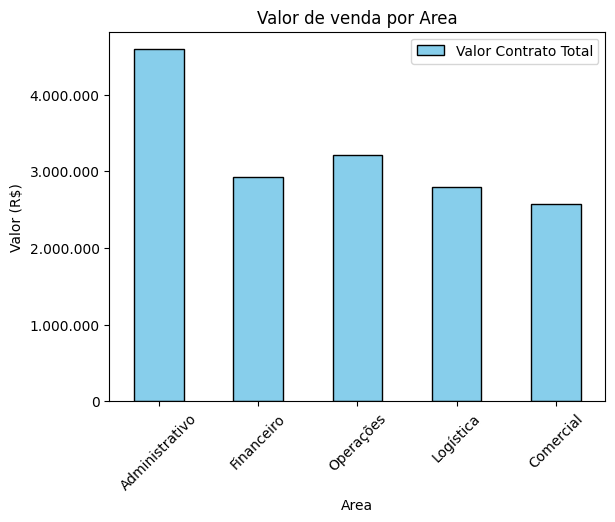

----------------------------------------------------------------------
A média geral dos valores dos contratos é R$ 23.287,59
----------------------------------------------------------------------
A media dos valores dos contratos é R$ 23.287,59


In [27]:
funcionarios_df = pd.read_csv(r'CadastroFuncionarios.csv', sep=';', engine = 'python')
clientes_df = pd.read_csv(r'CadastroClientes.csv', sep=';', engine = 'python')
servicos_df = pd.read_excel(r'BaseServiçosPrestados.xlsx')

colunas_financeiras = ['Salario Base','Impostos','Beneficios']

for coluna in colunas_financeiras:
    funcionarios_df[coluna] = funcionarios_df[coluna].astype(str).str.replace(',', '.').astype(float)

gasto_total = funcionarios_df['Salario Base'].sum() + \
              funcionarios_df['Impostos'].sum() + \
              funcionarios_df['Beneficios'].sum()
 
gastototal_formatado = f'{gasto_total:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
print(f'O gasto total da folha salarial da empresa é R$ {gastototal_formatado}')
print('-' * 70)

tabela_final_df = pd.merge(clientes_df, servicos_df, on='ID Cliente')
tabela_final_df['Valor Contrato Total'] = tabela_final_df.eval(
    '`Valor Contrato Mensal` * `Tempo Total de Contrato (Meses)`'
)

valor_faturamento = tabela_final_df['Valor Contrato Total'].sum()
faturamento_formatado = f'{valor_faturamento:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
print(f'O faturamento total da empresa é R$ {faturamento_formatado}')
print('-' * 70)


vendedores_unicos = servicos_df['ID Funcionário'].nunique()
print(f'A porcentagen de funcionarios que fecharam ao menos uma venda é de {(vendedores_unicos / len(funcionarios_df)):.2%}')
print('-' * 70)


contrato_areas_df = pd.merge(
    servicos_df[['ID Funcionário', 'Tempo Total de Contrato (Meses)']], 
    funcionarios_df[['ID Funcionário', 'Area']], 
    on = 'ID Funcionário',
)
contrato_areas_df = pd.merge(
    contrato_areas_df, 
    tabela_final_df[['ID Funcionário', 'Valor Contrato Total']],
    on = 'ID Funcionário',
)

vendas_por_area = contrato_areas_df.groupby('Area')[['Valor Contrato Total']].sum().reset_index()

print("1. Faturamento por Área:")
display(vendas_por_area.set_index('Area'))
print('-' * 70)

funcionarios_area = funcionarios_df.groupby('Area')[['ID Funcionário']].count().reset_index()
funcionarios_area = funcionarios_area.rename(columns={'ID Funcionário': 'Total de Funcionários'})

print("2. Total de Funcionários por Área:")
display(funcionarios_area.set_index('Area'))
print('-' * 70)

resumo_geral = pd.merge(vendas_por_area, funcionarios_area, on='Area')

resumo_geral['Ticket Médio por Funcionário'] = resumo_geral['Valor Contrato Total'] / resumo_geral['Total de Funcionários']

resumo_geral = resumo_geral.sort_values(by='Ticket Médio por Funcionário', ascending=False)

print("3. Resumo de Produtividade por Área:")
display(resumo_geral.set_index('Area'))
ax = resumo_geral.plot(kind='bar', x='Area', y='Valor Contrato Total', color='skyblue', edgecolor='black')
ax.get_yaxis().set_major_formatter(
    ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.'))
)
plt.title('Valor de venda por Area')
plt.ylabel('Valor (R$)')
plt.xticks(rotation=45)
plt.show()
print('-' * 70)

media_contratos = tabela_final_df['Valor Contrato Total'].mean()
media_contratos_formatado = f'{media_contratos:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
print(f'A média geral dos valores dos contratos é R$ {media_contratos_formatado}')
print('-' * 70)


media_contratos = tabela_final_df['Valor Contrato Total'].mean()
media_contratos_formatado = f'{media_contratos:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
print(f'A media dos valores dos contratos é R$ {media_contratos_formatado}')



#display(contrato_areas_df)
#display(funcionarios_df)
#display(clientes_df)
#display(servicos_df)
#display(tabela_final_df)